In [1]:
import numpy as np
import pandas as pd
import json
import warnings
import joblib
import pickle
import random
from pathlib import Path
from datetime import datetime
from collections import Counter
 
warnings.filterwarnings('ignore')
 
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve, auc,
    precision_score, recall_score, precision_recall_curve
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
 
RANDOM_STATE    = 42
RF_N_ESTIMATORS = 150


In [2]:
DATA_PATH  = Path(r"C:\Users\Sarika\Downloads\archive\UNSW-NB15_c")
TRAIN_FILE = "UNSW_NB15_training-set.csv"
TEST_FILE  = "UNSW_NB15_testing-set.csv"
 
train_df = pd.read_csv(DATA_PATH / TRAIN_FILE)
test_df  = pd.read_csv(DATA_PATH / TEST_FILE)
 
print(f"Train : {train_df.shape}")
print(f"Test  : {test_df.shape}")



Train : (82332, 45)
Test  : (175341, 45)


In [3]:
def explore_dataset(df, name="Dataset"):
    print(f"EXPLORING: {name.upper()}")
    print(f"  Shape        : {df.shape}")
    print(f"  Memory       : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")
 
    if 'label' in df.columns:
        print("  LABEL DISTRIBUTION")
        counts   = df['label'].value_counts()
        percents = df['label'].value_counts(normalize=True) * 100
        for label, count in counts.items():
            tag = "NORMAL" if label == 0 else "ATTACK"
            print(f"    {tag} ({label}): {count:,}  ({percents[label]:.1f}%)")
 
    if 'attack_cat' in df.columns:
        print(" ATTACK CATEGORIES")
        for attack, count in df['attack_cat'].value_counts().items():
            print(f"    {attack:<25}: {count:>6,}")
 
    print("  DATA TYPES")
    print(df.dtypes.value_counts().to_string())
 
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n  MISSING VALUES (total: {missing.sum():,})")
        for col, cnt in missing[missing > 0].items():
            print(f"    {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
    else:
        print("  No missing values.")
 
    num_cols = df.select_dtypes(include=[np.number]).columns
    print(f"\n  NUMERIC FEATURE SUMMARY ({len(num_cols)} columns)")
    print(df[num_cols].describe().T[['mean', 'std', 'min', 'max']].round(2).to_string())
 
 
explore_dataset(train_df, 'Training Data')
print(f"\n{'-'*50}")
explore_dataset(test_df,  'Testing Data')

EXPLORING: TRAINING DATA
  Shape        : (82332, 45)
  Memory       : 42.32 MB
  LABEL DISTRIBUTION
    ATTACK (1): 45,332  (55.1%)
    NORMAL (0): 37,000  (44.9%)
 ATTACK CATEGORIES
    Normal                   : 37,000
    Generic                  : 18,871
    Exploits                 : 11,132
    Fuzzers                  :  6,062
    DoS                      :  4,089
    Reconnaissance           :  3,496
    Analysis                 :    677
    Backdoor                 :    583
    Shellcode                :    378
    Worms                    :     44
  DATA TYPES
int64      30
float64    11
object      4
  No missing values.

  NUMERIC FEATURE SUMMARY (41 columns)
                           mean           std   min           max
id                 4.116650e+04  2.376735e+04   1.0  8.233200e+04
dur                1.010000e+00  4.710000e+00   0.0  6.000000e+01
spkts              1.867000e+01  1.339200e+02   1.0  1.064600e+04
dpkts              1.755000e+01  1.155700e+02   0.0  1.1

In [4]:
print("CLEANING DATA")
 
for df in [train_df, test_df]:
# Drop row identifier ( not a feature)
    if 'id' in df.columns:
        df.drop('id', axis=1, inplace=True)
 
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)
 

assert not train_df.isnull().any().any(), "NaNs remain in train!"
assert not test_df.isnull().any().any(),  "NaNs remain in test!"
print("Cleaning complete. No nulls or infs remain.")

CLEANING DATA
Cleaning complete. No nulls or infs remain.


In [5]:
print("SEPARATING FEATURES AND LABELS ")
 
X_train_raw = train_df.drop(['label', 'attack_cat'], axis=1, errors='ignore')
y_train      = train_df['label'].values
X_test_raw   = test_df.drop(['label', 'attack_cat'], axis=1, errors='ignore')
y_test       = test_df['label'].values
 
print(f"X_train : {X_train_raw.shape}  |  classes: {np.unique(y_train)}")
print(f"X_test  : {X_test_raw.shape}   |  classes: {np.unique(y_test)}")
print(f"Train — Normal: {(y_train==0).sum():,}  Attack: {(y_train==1).sum():,}")
print(f"Test  — Normal: {(y_test==0).sum():,}   Attack: {(y_test==1).sum():,}")

SEPARATING FEATURES AND LABELS 
X_train : (82332, 42)  |  classes: [0 1]
X_test  : (175341, 42)   |  classes: [0 1]
Train — Normal: 37,000  Attack: 45,332
Test  — Normal: 56,000   Attack: 119,341


In [6]:
print("ENCODING CATEGORICAL COLUMNS ")
 
X_train_enc = X_train_raw.copy()
X_test_enc  = X_test_raw.copy()
 
cat_cols = X_train_enc.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")
 
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
    label_encoders[col] = le
 
    if col in X_test_enc.columns:
        known = set(le.classes_)
        X_test_enc[col] = (
            X_test_enc[col].astype(str)
            .apply(lambda v: le.transform([v])[0] if v in known else -1)
        )
    else:
        print(f"  WARNING: '{col}' not in test — filling 0")
        X_test_enc[col] = 0
 
assert X_train_enc.select_dtypes(include='object').empty, "Object cols remain in train!"
assert X_test_enc.select_dtypes(include='object').empty,  "Object cols remain in test!"
print(f"Encoding complete. Train: {X_train_enc.shape}  Test: {X_test_enc.shape}")

ENCODING CATEGORICAL COLUMNS 
Categorical columns: ['proto', 'service', 'state']
Encoding complete. Train: (82332, 42)  Test: (175341, 42)


In [7]:
print(" FEATURE SELECTION ")
 
TOP_FEATURES = [
    'dur', 'sbytes', 'dbytes', 'rate', 'sttl',
    'sload', 'dload', 'spkts', 'dpkts',
    'proto', 'service', 'state',
    'dttl', 'sinpkt', 'dinpkt'
]
BACKUP_FEATURES = ['ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm']
 
available = [f for f in TOP_FEATURES if f in X_train_enc.columns]
if len(available) < 9:
    # Must have at least the 9 app.py features
    for f in BACKUP_FEATURES:
        if f in X_train_enc.columns and f not in available:
            available.append(f)
 
print(f"Selected {len(available)} features:")
for i, f in enumerate(available, 1):
    print(f"  {i:2}. {f}")
 
X_train_sel = X_train_enc[available].copy()
X_test_sel  = X_test_enc[available].copy()
 

 FEATURE SELECTION 
Selected 15 features:
   1. dur
   2. sbytes
   3. dbytes
   4. rate
   5. sttl
   6. sload
   7. dload
   8. spkts
   9. dpkts
  10. proto
  11. service
  12. state
  13. dttl
  14. sinpkt
  15. dinpkt


In [8]:
print("SCALING FEATURES ")
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)
 
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print(f"Train mean ≈ {X_train_scaled.mean():.4f}  std ≈ {X_train_scaled.std():.4f}")

SCALING FEATURES 
X_train_scaled : (82332, 15)
X_test_scaled  : (175341, 15)
Train mean ≈ -0.0000  std ≈ 1.0000


In [9]:
print(" TRAINING MODELS (DUAL-GUARD ARCHITECTURE) ")
 
attack_ratio = float((y_train == 1).sum() / len(y_train))
print(f"Attack ratio in train : {attack_ratio:.4f} ({attack_ratio*100:.1f}%)")
 
print("[Guard 1] Training Random Forest")
rf_model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced',
    bootstrap=True,
    oob_score=True,
    verbose=0
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf  = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
print(f"  OOB score : {rf_model.oob_score_:.4f}")
 
# contamination='auto' use decision_function() scores at inference
# so contamination only affects sklearn's internal offset, not our logic.
print("[Guard 2] Training Isolation Forest on normal traffic only")
normal_mask = (y_train == 0)
X_normal    = X_train_scaled[normal_mask]
 
iso_model = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=RANDOM_STATE,
    verbose=0,
    n_jobs=1
)
iso_model.fit(X_normal)
print(f"  Trained on {len(X_normal):,} normal samples")
 
print("[Dual-Guard] Applying detection")
 
# Guard 2 scores on full test set (more negative = more anomalous)
iso_scores_test = iso_model.decision_function(X_test_scaled)
 
# Calibrate cutoff on RF-normal pool scores only
# Bottom SUSPICION_PERCENTILE% of what RF passed = most anomalous "normal" traffic
rf_normal_mask   = (y_pred_rf == 0)
rf_normal_scores = iso_scores_test[rf_normal_mask]
 
SUSPICION_PERCENTILE = 10   # tunable: lower = stricter Guard 2
score_cutoff = float(np.percentile(rf_normal_scores, SUSPICION_PERCENTILE))
print(f"  Suspicion score cutoff (p{SUSPICION_PERCENTILE}): {score_cutoff:.4f}")
 
# 0 = NORMAL, 1 = ATTACK (RF), 2 = SUSPICIOUS 
y_pred_cascade = np.zeros(len(y_test), dtype=int)
y_pred_cascade[y_pred_rf == 1] = 1
 
rf_normal_idx   = np.where(rf_normal_mask)[0]
suspicious_mask = iso_scores_test[rf_normal_mask] < score_cutoff
suspicious_idx  = rf_normal_idx[suspicious_mask]
y_pred_cascade[suspicious_idx] = 2
 
n_attack     = (y_pred_cascade == 1).sum()
n_suspicious = (y_pred_cascade == 2).sum()
n_normal     = (y_pred_cascade == 0).sum()
print(f"  Guard 1 flagged ATTACK    : {n_attack:,}")
print(f"  Guard 2 flagged SUSPICIOUS: {n_suspicious:,}  "
      f"(bottom {SUSPICION_PERCENTILE}% anomaly scores in RF-normal pool)")
print(f"  Passed as NORMAL          : {n_normal:,}")
 
# Binary for standard metrics: ATTACK + SUSPICIOUS = positive
y_pred_final = (y_pred_cascade >= 1).astype(int)
 


 TRAINING MODELS (DUAL-GUARD ARCHITECTURE) 
Attack ratio in train : 0.5506 (55.1%)
[Guard 1] Training Random Forest
  OOB score : 0.9428
[Guard 2] Training Isolation Forest on normal traffic only
  Trained on 37,000 normal samples
[Dual-Guard] Applying detection
  Suspicion score cutoff (p10): 0.0014
  Guard 1 flagged ATTACK    : 107,036
  Guard 2 flagged SUSPICIOUS: 6,830  (bottom 10% anomaly scores in RF-normal pool)
  Passed as NORMAL          : 61,475


In [10]:
print("MODEL EVALUATION")
 
def evaluate(y_true, y_pred, y_proba=None, name="Model"):
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred, zero_division=0)
    rec     = recall_score(y_true, y_pred, zero_division=0)
    f1      = f1_score(y_true, y_pred, zero_division=0)
    cm      = confusion_matrix(y_true, y_pred)
    auc_val = roc_auc_score(y_true, y_proba) if y_proba is not None else None
 
    print(f"\n{'-'*40}")
    print(f"  {name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    if auc_val:
        print(f"  ROC-AUC   : {auc_val:.4f}")
    print(f"  Missed Attacks (FN) : {cm[1,0]:,}")
    print(f"  False Alarms   (FP) : {cm[0,1]:,}")
    print(f"  FN Rate : {cm[1,0]/cm[1].sum()*100:.1f}%")
    print(f"  FP Rate : {cm[0,1]/cm[0].sum()*100:.1f}%")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Normal','Attack'], digits=4)}")
    return {
        'name': name, 'acc': acc, 'prec': prec,
        'rec': rec, 'f1': f1, 'auc': auc_val, 'cm': cm,
        'fn': int(cm[1,0]), 'fp': int(cm[0,1]),
        'tp': int(cm[1,1]), 'tn': int(cm[0,0])
    }
 
rf_results      = evaluate(y_test, y_pred_rf,    y_proba_rf, "Guard 1: Random Forest only")
cascade_results = evaluate(y_test, y_pred_final, None,       "Dual-Guard (RF + IF)")
 
# Guard 2 contribution breakdown
rf_fn_mask        = (y_pred_rf == 0) & (y_test == 1)
cascade_recovered = int(((y_pred_cascade == 2) & (y_test == 1)).sum())
cascade_new_fp    = int(((y_pred_cascade == 2) & (y_test == 0)).sum())
 
print(f"\n GUARD 2 CONTRIBUTION (p{SUSPICION_PERCENTILE} cutoff) ")
print(f"  Attacks Guard 1 missed          : {rf_fn_mask.sum():,}")
print(f"  Attacks Guard 2 recovered       : {cascade_recovered:,}  "
      f"({cascade_recovered/max(rf_fn_mask.sum(),1)*100:.1f}% of Guard 1 misses)")
print(f"  New false alarms from Guard 2   : {cascade_new_fp:,}")
print(f"  Recovery ratio                  : "
      f"{cascade_recovered}/{cascade_new_fp} = "
      f"{cascade_recovered/max(cascade_new_fp,1):.2f} attacks per false alarm")
print(f"\n  NOTE: adjust SUSPICION_PERCENTILE (currently {SUSPICION_PERCENTILE}%) to tune")
print(f"  Guard 2 aggression. Lower = stricter = fewer flags, fewer FP.")
 
# Alias for downstream cells
iso_results = cascade_results

MODEL EVALUATION

----------------------------------------
  Guard 1: Random Forest only
  Accuracy  : 0.9088
  Precision : 0.9828
  Recall    : 0.8815
  F1-Score  : 0.9294
  ROC-AUC   : 0.9856
  Missed Attacks (FN) : 14,145
  False Alarms   (FP) : 1,840
  FN Rate : 11.9%
  FP Rate : 3.3%

              precision    recall  f1-score   support

      Normal     0.7929    0.9671    0.8714     56000
      Attack     0.9828    0.8815    0.9294    119341

    accuracy                         0.9088    175341
   macro avg     0.8879    0.9243    0.9004    175341
weighted avg     0.9222    0.9088    0.9109    175341


----------------------------------------
  Dual-Guard (RF + IF)
  Accuracy  : 0.8817
  Precision : 0.9330
  Recall    : 0.8902
  F1-Score  : 0.9111
  Missed Attacks (FN) : 13,106
  False Alarms   (FP) : 7,631
  FN Rate : 11.0%
  FP Rate : 13.6%

              precision    recall  f1-score   support

      Normal     0.7868    0.8637    0.8235     56000
      Attack     0.9330   

In [11]:
print("MODEL EVALUATION ")
 
def evaluate(y_true, y_pred, y_proba=None, name="Model"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    auc_val = roc_auc_score(y_true, y_proba) if y_proba is not None else None
 
    print(f"\n{'-'*40}")
    print(f"  {name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    if auc_val:
        print(f"  ROC-AUC   : {auc_val:.4f}")
    print(f"  Missed Attacks (FN) : {cm[1,0]:,}")
    print(f"  False Alarms   (FP) : {cm[0,1]:,}")
    print(f"  FN Rate : {cm[1,0]/cm[1].sum()*100:.1f}%")
    print(f"  FP Rate : {cm[0,1]/cm[0].sum()*100:.1f}%")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Normal','Attack'], digits=4)}")
 
    return {
        'name': name, 'acc': acc, 'prec': prec,
        'rec': rec, 'f1': f1, 'auc': auc_val, 'cm': cm,
        'fn': int(cm[1,0]), 'fp': int(cm[0,1]),
        'tp': int(cm[1,1]), 'tn': int(cm[0,0])
    }
 
# Evaluate RF alone (baseline)
rf_results       = evaluate(y_test, y_pred_rf,    y_proba_rf, "Random Forest (Stage 1 only)")
 
# Evaluate cascade
cascade_results  = evaluate(y_test, y_pred_final, None,       "Cascade (RF + IF)")
 
#cascade recovered
rf_fn_mask       = (y_pred_rf == 0) & (y_test == 1)   # attacks RF missed
cascade_recovered= ((y_pred_cascade == 2) & (y_test == 1)).sum()
cascade_new_fp   = ((y_pred_cascade == 2) & (y_test == 0)).sum()
 
print(f"CASCADE CONTRIBUTION")
print(f"  Attacks RF missed            : {rf_fn_mask.sum():,}")
print(f"  Attacks IF recovered         : {cascade_recovered:,}  "
      f"({cascade_recovered/max(rf_fn_mask.sum(),1)*100:.1f}% of RF misses)")
print(f"  New false alarms from IF     : {cascade_new_fp:,}")
print(f"  Net: recovered {cascade_recovered:,} attacks at cost of {cascade_new_fp:,} extra false alarms")
 
iso_results = cascade_results  

MODEL EVALUATION 

----------------------------------------
  Random Forest (Stage 1 only)
  Accuracy  : 0.9088
  Precision : 0.9828
  Recall    : 0.8815
  F1-Score  : 0.9294
  ROC-AUC   : 0.9856
  Missed Attacks (FN) : 14,145
  False Alarms   (FP) : 1,840
  FN Rate : 11.9%
  FP Rate : 3.3%

              precision    recall  f1-score   support

      Normal     0.7929    0.9671    0.8714     56000
      Attack     0.9828    0.8815    0.9294    119341

    accuracy                         0.9088    175341
   macro avg     0.8879    0.9243    0.9004    175341
weighted avg     0.9222    0.9088    0.9109    175341


----------------------------------------
  Cascade (RF + IF)
  Accuracy  : 0.8817
  Precision : 0.9330
  Recall    : 0.8902
  F1-Score  : 0.9111
  Missed Attacks (FN) : 13,106
  False Alarms   (FP) : 7,631
  FN Rate : 11.0%
  FP Rate : 13.6%

              precision    recall  f1-score   support

      Normal     0.7868    0.8637    0.8235     56000
      Attack     0.9330    

In [15]:
print("THRESHOLD TUNING WITH CROSS-VALIDATION")
 
THRESHOLDS   = np.arange(0.10, 0.90, 0.05)
N_FOLDS      = 5
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
 
# per-threshold F1 scores across folds
cv_f1_per_threshold = {float(t): [] for t in THRESHOLDS}
 
print(f"Running {N_FOLDS}-fold CV threshold sweep")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), 1):
    X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train[tr_idx],        y_train[val_idx]
 
    # Train a fold-specific RF — same hyperparams as the final model
    fold_rf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced',
        bootstrap=True,
        oob_score=False,
        verbose=0
    )
    fold_rf.fit(X_tr, y_tr)
    val_proba = fold_rf.predict_proba(X_val)[:, 1]
 
    for thresh in THRESHOLDS:
        y_adj = (val_proba >= thresh).astype(int)
        cv_f1_per_threshold[float(thresh)].append(
            f1_score(y_val, y_adj, zero_division=0)
        )
    print(f"  Fold {fold}/{N_FOLDS} done.")
 
cv_mean_f1 = {t: float(np.mean(scores)) for t, scores in cv_f1_per_threshold.items()}
cv_std_f1  = {t: float(np.std(scores))  for t, scores in cv_f1_per_threshold.items()}
 
# Best threshold = highest mean CV F1
best_threshold = max(cv_mean_f1, key=cv_mean_f1.get)
best_cv_f1     = cv_mean_f1[best_threshold]
best_cv_std    = cv_std_f1[best_threshold]
 
print(f"\nCV Results:")
print(f"  {'Threshold':>10}  {'Mean F1':>8}  {'Std':>6}")
for t in sorted(cv_mean_f1.keys()):
    marker = " ← best" if t == best_threshold else ""
    print(f"  {t:>10.2f}  {cv_mean_f1[t]:>8.4f}  {cv_std_f1[t]:>6.4f}{marker}")
 
# Apply CV-selected threshold to test set ONCE
# This is the honest reported number. Test set was never touched during tuning.
y_pred_default   = (y_proba_rf >= 0.50).astype(int)
y_pred_optimized = (y_proba_rf >= best_threshold).astype(int)
default_f1       = f1_score(y_test, y_pred_default,   zero_division=0)
optimized_f1     = f1_score(y_test, y_pred_optimized, zero_division=0)
cm_opt           = confusion_matrix(y_test, y_pred_optimized)
 
print(f"\nTest Set Results (threshold selected by CV — not tuned on test):")
print(f"  Default  θ=0.50 : F1 = {default_f1:.4f}")
print(f"  Optimal  θ={best_threshold:.2f} : F1 = {optimized_f1:.4f}  "
      f"(CV mean={best_cv_f1:.4f} ± {best_cv_std:.4f})")
print(f"  Improvement      : +{(optimized_f1 - default_f1)*100:.2f}%")
print(f"\nOptimized metrics at θ={best_threshold:.2f}:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_optimized, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_optimized, zero_division=0):.4f}")
print(f"  F1-Score  : {optimized_f1:.4f}")
 
# ROC and Precision-Recall curves 
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_rf)
roc_auc_val               = auc(fpr, tpr)
 
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, y_proba_rf)
pr_auc_val                              = auc(pr_recall, pr_precision)
 
#threshold_results list for saving — includes CV mean F1
threshold_results = [
    {
        'threshold'  : t,
        'cv_mean_f1' : cv_mean_f1[t],
        'cv_std_f1'  : cv_std_f1[t],
        # Also compute test-set metrics per threshold for the app's display curve
        'test_f1'    : float(f1_score(y_test, (y_proba_rf >= t).astype(int), zero_division=0)),
        'test_prec'  : float(precision_score(y_test, (y_proba_rf >= t).astype(int), zero_division=0)),
        'test_recall': float(recall_score(y_test, (y_proba_rf >= t).astype(int), zero_division=0)),
    }
    for t in sorted(cv_mean_f1.keys())
]
 
print(f"\nROC-AUC  : {roc_auc_val:.4f}")
print(f"PR-AUC   : {pr_auc_val:.4f}")
print(f"Note: improvement claim ({(optimized_f1 - default_f1)*100:.2f}%) is "
      f"validated by CV — threshold was not selected using the test set.")
 
# Pre-compute optimized metrics used in visualization cell
opt_f1   = float(f1_score(y_test, y_pred_optimized, zero_division=0))
opt_prec = float(precision_score(y_test, y_pred_optimized, zero_division=0))
opt_rec  = float(recall_score(y_test, y_pred_optimized, zero_division=0))
opt_acc  = float(accuracy_score(y_test, y_pred_optimized))
 

THRESHOLD TUNING WITH CROSS-VALIDATION
Running 5-fold CV threshold sweep
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.

CV Results:
   Threshold   Mean F1     Std
        0.10    0.8902  0.0018
        0.15    0.9122  0.0011
        0.20    0.9261  0.0011
        0.25    0.9342  0.0013
        0.30    0.9400  0.0017
        0.35    0.9437  0.0016
        0.40    0.9457  0.0016
        0.45    0.9459  0.0015 ← best
        0.50    0.9459  0.0016
        0.55    0.9451  0.0017
        0.60    0.9437  0.0016
        0.65    0.9414  0.0020
        0.70    0.9386  0.0021
        0.75    0.9349  0.0024
        0.80    0.9309  0.0021
        0.85    0.9258  0.0018

Test Set Results (threshold selected by CV — not tuned on test):
  Default  θ=0.50 : F1 = 0.9294
  Optimal  θ=0.45 : F1 = 0.9332  (CV mean=0.9459 ± 0.0015)
  Improvement      : +0.38%

Optimized metrics at θ=0.45:
  Accuracy  : 0.9132
  Precision : 0.9798
  Recall    : 0.8908
  F1-Score  : 0.9

CREATING VISUALIZATIONS
Saved: cybershield_pr_curve.png


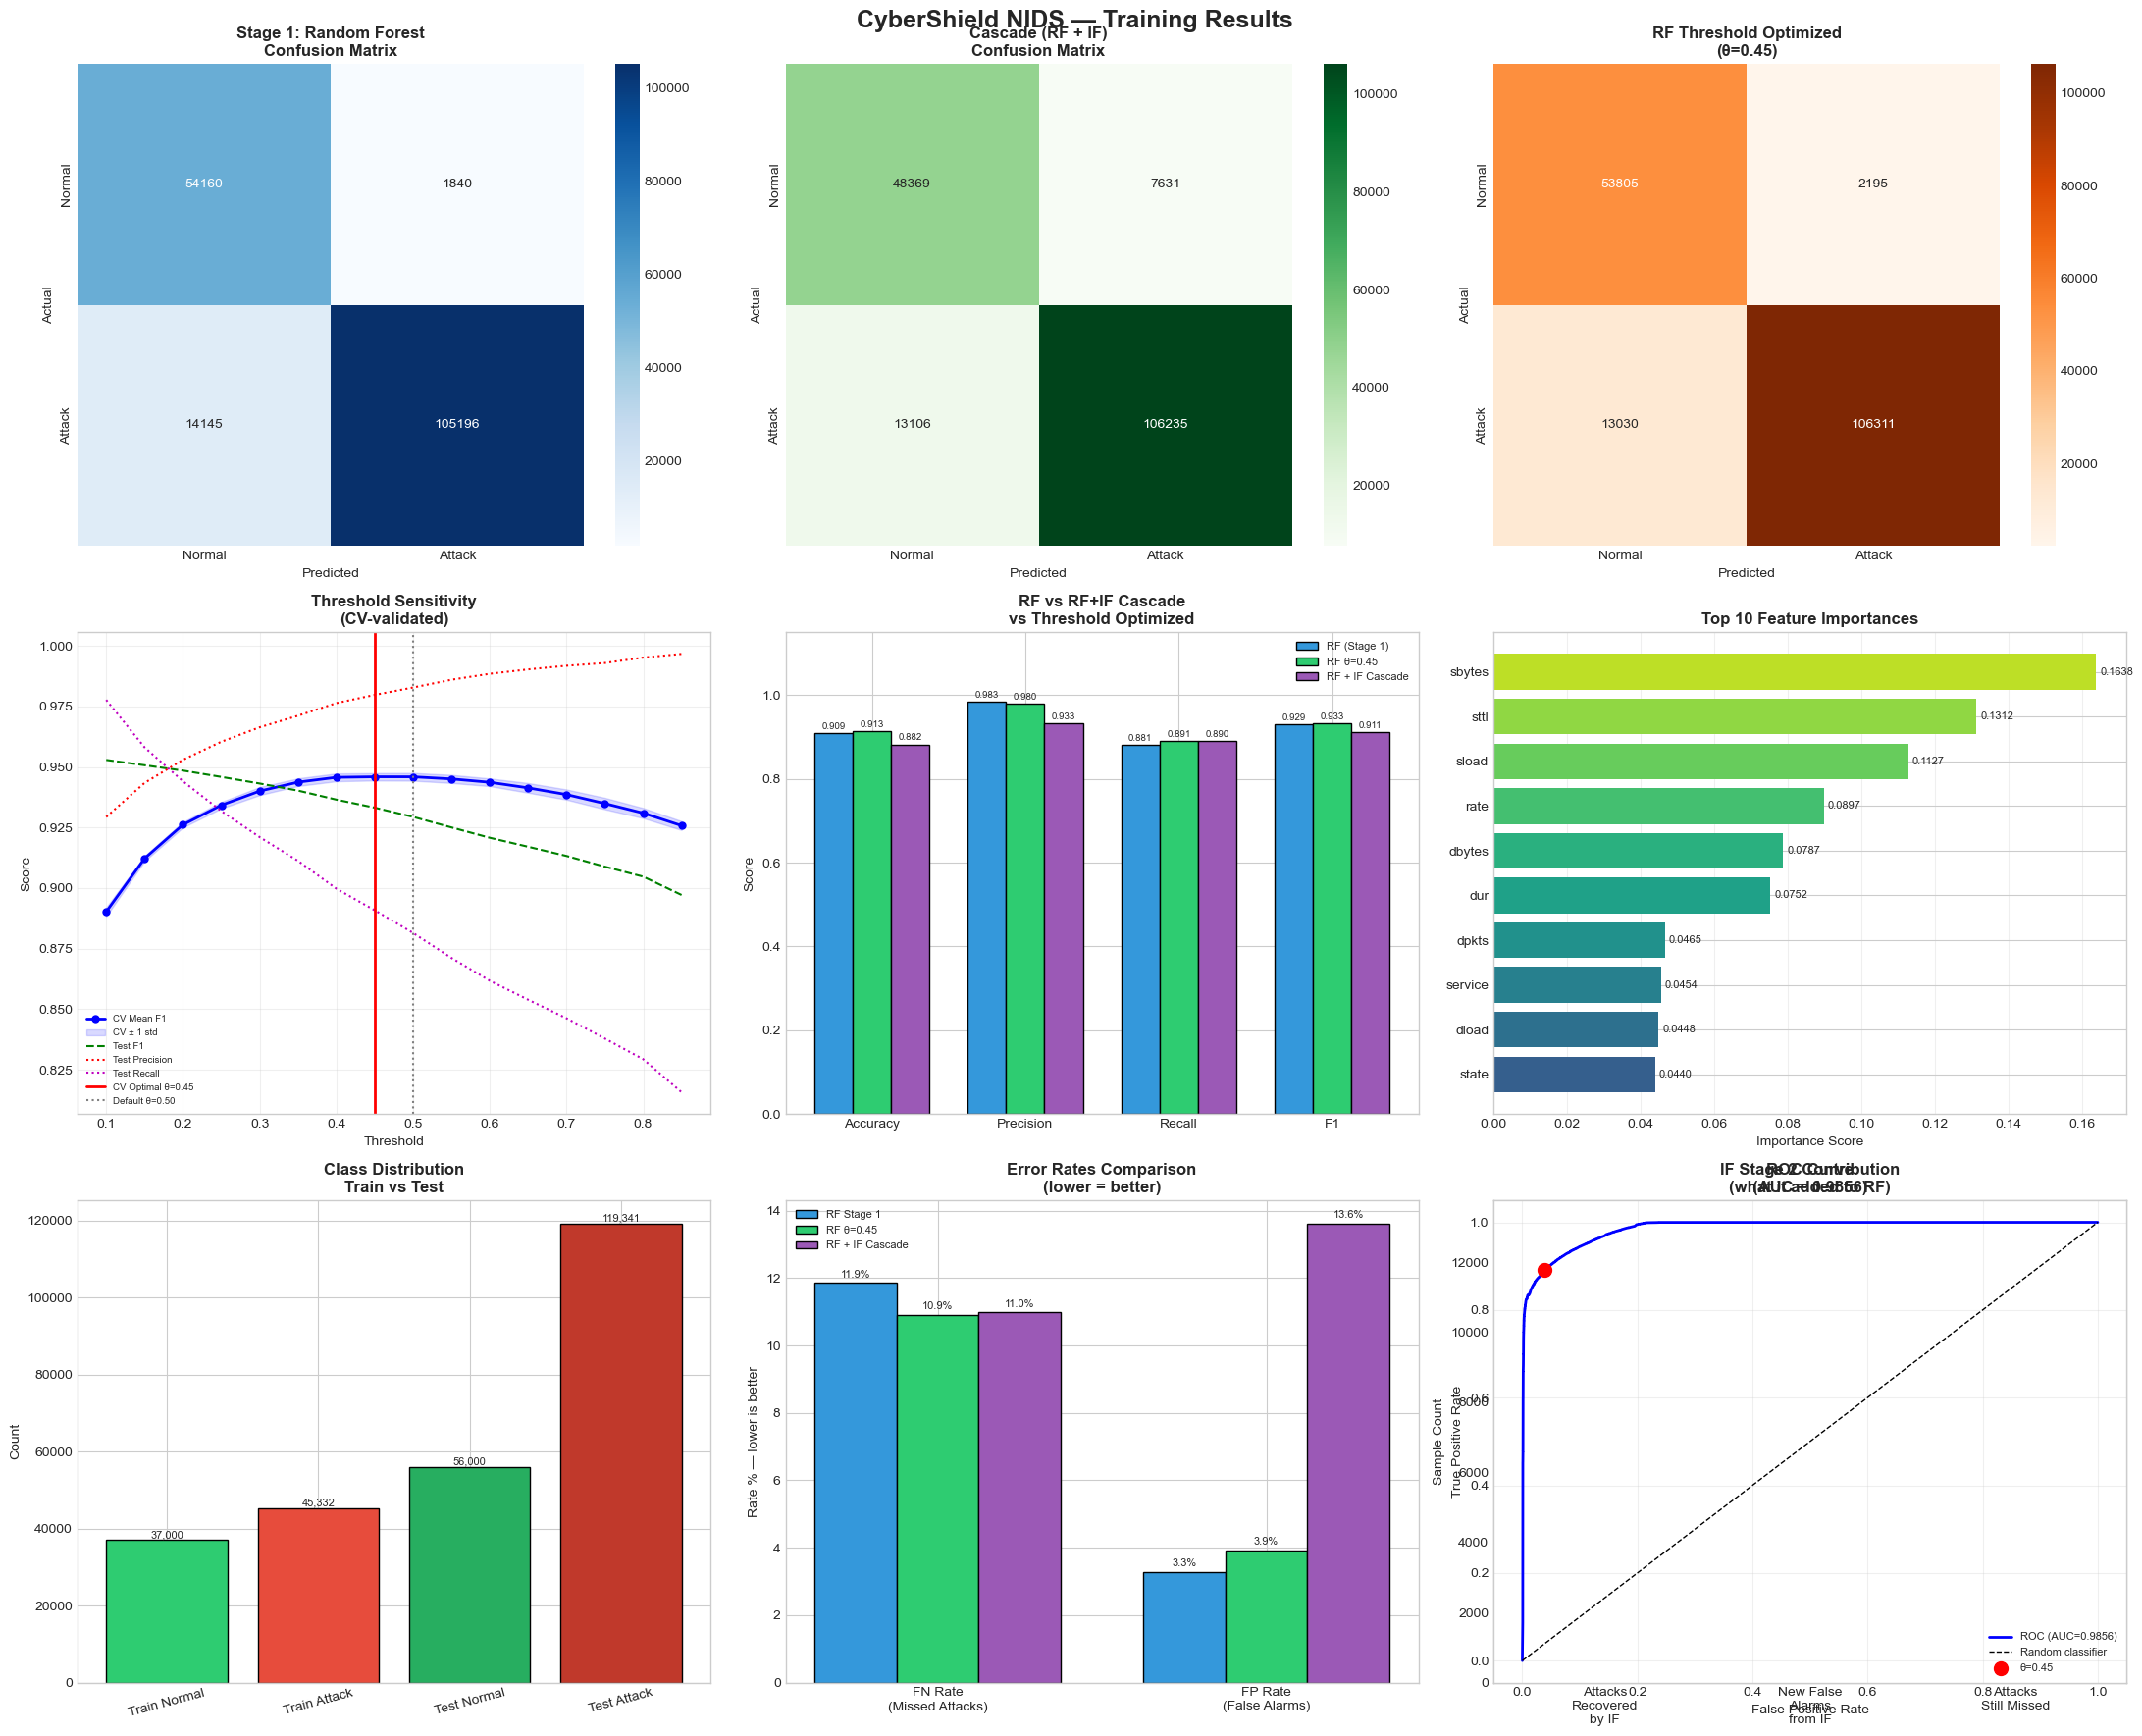

Saved: cybershield_training_results.png


In [13]:
print("CREATING VISUALIZATIONS")
 
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(22, 18))
fig.suptitle('CyberShield NIDS — Training Results', fontsize=18, fontweight='bold', y=0.98)
 
# Plot 1: RF Confusion Matrix
ax1 = fig.add_subplot(3, 3, 1)
sns.heatmap(rf_results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], ax=ax1)
ax1.set_title('Stage 1: Random Forest\nConfusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
 
# Plot 2: Cascade Confusion Matrix
ax2 = fig.add_subplot(3, 3, 2)
sns.heatmap(cascade_results['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], ax=ax2)
ax2.set_title('Cascade (RF + IF)\nConfusion Matrix', fontweight='bold')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
 
# Plot 3: Optimized RF Confusion Matrix
ax3 = fig.add_subplot(3, 3, 3)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], ax=ax3)
ax3.set_title(f'RF Threshold Optimized\n(θ={best_threshold:.2f})', fontweight='bold')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')
 
# Plot 4: Threshold Tuning — CV mean F1 vs test F1
ax4 = fig.add_subplot(3, 3, 4)
thresh_list    = [r['threshold']   for r in threshold_results]
cv_f1_list     = [r['cv_mean_f1']  for r in threshold_results]
cv_std_list    = [r['cv_std_f1']   for r in threshold_results]
test_f1_list   = [r['test_f1']     for r in threshold_results]
test_prec_list = [r['test_prec']   for r in threshold_results]
test_rec_list  = [r['test_recall'] for r in threshold_results]
 
ax4.plot(thresh_list, cv_f1_list,   'b-o', linewidth=2, markersize=5, label='CV Mean F1')
ax4.fill_between(thresh_list,
                 [f - s for f, s in zip(cv_f1_list, cv_std_list)],
                 [f + s for f, s in zip(cv_f1_list, cv_std_list)],
                 alpha=0.15, color='blue', label='CV ± 1 std')
ax4.plot(thresh_list, test_f1_list,   'g--',  linewidth=1.5, label='Test F1')
ax4.plot(thresh_list, test_prec_list, 'r:',   linewidth=1.5, label='Test Precision')
ax4.plot(thresh_list, test_rec_list,  'm:',   linewidth=1.5, label='Test Recall')
ax4.axvline(x=best_threshold, color='red', linestyle='-', linewidth=2,
            label=f'CV Optimal θ={best_threshold:.2f}')
ax4.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Default θ=0.50')
ax4.set_xlabel('Threshold'); ax4.set_ylabel('Score')
ax4.set_title('Threshold Sensitivity\n(CV-validated)', fontweight='bold')
ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3)
 
# Plot 5: RF vs Cascade vs RF-Optimized
ax5 = fig.add_subplot(3, 3, 5)
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1']
rf_scores  = [rf_results['acc'],      rf_results['prec'],      rf_results['rec'],      rf_results['f1']]
cas_scores = [cascade_results['acc'], cascade_results['prec'], cascade_results['rec'], cascade_results['f1']]
opt_scores = [opt_acc, opt_prec, opt_rec, opt_f1]
x = np.arange(len(metrics)); w = 0.25
b1 = ax5.bar(x - w, rf_scores,  w, label='RF (Stage 1)',      color='#3498db', edgecolor='black')
b2 = ax5.bar(x,     opt_scores, w, label=f'RF θ={best_threshold:.2f}', color='#2ecc71', edgecolor='black')
b3 = ax5.bar(x + w, cas_scores, w, label='RF + IF Cascade',   color='#9b59b6', edgecolor='black')
for bars in [b1, b2, b3]:
    for bar in bars:
        ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax5.set_xticks(x); ax5.set_xticklabels(metrics)
ax5.set_ylim(0, 1.15); ax5.set_ylabel('Score')
ax5.set_title('RF vs RF+IF Cascade\nvs Threshold Optimized', fontweight='bold')
ax5.legend(fontsize=8)
 
# Plot 6: Feature Importance
ax6 = fig.add_subplot(3, 3, 6)
feat_imp = pd.DataFrame({
    'Feature'   : available,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
top_n  = min(10, len(feat_imp))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
bars   = ax6.barh(feat_imp['Feature'].head(top_n)[::-1],
                  feat_imp['Importance'].head(top_n)[::-1], color=colors)
for bar, imp in zip(bars, feat_imp['Importance'].head(top_n)[::-1]):
    ax6.text(imp+0.001, bar.get_y()+bar.get_height()/2,
             f'{imp:.4f}', ha='left', va='center', fontsize=8)
ax6.set_title(f'Top {top_n} Feature Importances', fontweight='bold')
ax6.set_xlabel('Importance Score')
ax6.grid(True, alpha=0.3, axis='x')
 
# Plot 7: Class Distribution
ax7 = fig.add_subplot(3, 3, 7)
cats   = ['Train Normal', 'Train Attack', 'Test Normal', 'Test Attack']
cnts   = [(y_train==0).sum(), (y_train==1).sum(), (y_test==0).sum(), (y_test==1).sum()]
bcolors= ['#2ecc71','#e74c3c','#27ae60','#c0392b']
bars7  = ax7.bar(cats, cnts, color=bcolors, edgecolor='black')
for bar, cnt in zip(bars7, cnts):
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
             f'{cnt:,}', ha='center', va='bottom', fontsize=8)
ax7.set_title('Class Distribution\nTrain vs Test', fontweight='bold')
ax7.set_ylabel('Count'); ax7.tick_params(axis='x', rotation=15)
 
# Plot 8: FN/FP Rate Comparison
ax8 = fig.add_subplot(3, 3, 8)
labels8  = ['FN Rate\n(Missed Attacks)', 'FP Rate\n(False Alarms)']
rf_err   = [rf_results['fn']/rf_results['cm'][1].sum()*100,
            rf_results['fp']/rf_results['cm'][0].sum()*100]
cas_err  = [cascade_results['fn']/cascade_results['cm'][1].sum()*100,
            cascade_results['fp']/cascade_results['cm'][0].sum()*100]
opt_err  = [cm_opt[1,0]/cm_opt[1].sum()*100, cm_opt[0,1]/cm_opt[0].sum()*100]
x8 = np.arange(len(labels8)); w8 = 0.25
e1 = ax8.bar(x8-w8, rf_err,  w8, label='RF Stage 1',          color='#3498db', edgecolor='black')
e2 = ax8.bar(x8,    opt_err, w8, label=f'RF θ={best_threshold:.2f}', color='#2ecc71', edgecolor='black')
e3 = ax8.bar(x8+w8, cas_err, w8, label='RF + IF Cascade',     color='#9b59b6', edgecolor='black')
for bars in [e1, e2, e3]:
    for bar in bars:
        ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax8.set_xticks(x8); ax8.set_xticklabels(labels8)
ax8.set_ylabel('Rate % — lower is better')
ax8.set_title('Error Rates Comparison\n(lower = better)', fontweight='bold')
ax8.legend(fontsize=8)
 
# Plot 9: Cascade IF contribution — what IF recovered vs new FP introduced
ax9 = fig.add_subplot(3, 3, 9)
contrib_labels = ['Attacks\nRecovered\nby IF', 'New False\nAlarms\nfrom IF',
                  'Attacks\nStill Missed']
contrib_vals   = [cascade_recovered, cascade_new_fp,
                  cascade_results['fn']]
contrib_colors = ['#2ecc71', '#e74c3c', '#e67e22']
bars9 = ax9.bar(contrib_labels, contrib_vals, color=contrib_colors, edgecolor='black')
for bar, val in zip(bars9, contrib_vals):
    ax9.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax9.set_ylabel('Sample Count')
ax9.set_title('IF Stage 2 Contribution\n(what it added to RF)', fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')
 
# Plot 9: ROC Curve
ax9 = fig.add_subplot(3, 3, 9)
ax9.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={roc_auc_val:.4f})')
ax9.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')

opt_idx = np.argmin(np.abs(roc_thresholds - best_threshold))
ax9.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, zorder=5,
            label=f'θ={best_threshold:.2f}')
ax9.set_xlabel('False Positive Rate'); ax9.set_ylabel('True Positive Rate')
ax9.set_title(f'ROC Curve\n(AUC = {roc_auc_val:.4f})', fontweight='bold')
ax9.legend(fontsize=8); ax9.grid(True, alpha=0.3)
 

fig_pr, ax_pr = plt.subplots(figsize=(7, 5))
ax_pr.plot(pr_recall, pr_precision, 'b-', linewidth=2,
           label=f'PR Curve (AUC={pr_auc_val:.4f})')

pr_opt_idx = np.argmin(np.abs(pr_thresholds - best_threshold))
ax_pr.scatter(pr_recall[pr_opt_idx], pr_precision[pr_opt_idx],
              color='red', s=100, zorder=5, label=f'θ={best_threshold:.2f}')
baseline = (y_test == 1).sum() / len(y_test)
ax_pr.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
              label=f'Baseline (random) = {baseline:.3f}')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve\n(directly shows threshold tradeoff)',
                fontweight='bold')
ax_pr.legend(fontsize=9); ax_pr.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cybershield_pr_curve.png', dpi=300, bbox_inches='tight')
plt.close(fig_pr)
print("Saved: cybershield_pr_curve.png")
 
plt.tight_layout()
plt.savefig('cybershield_training_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: cybershield_training_results.png")
 

In [17]:
print(" SAVING MODEL PACKAGE ")
 
# Error analysis computed from real model output 
error_analysis = {
    # Stage 1 RF metrics
    'rf_tp'          : rf_results['tp'],
    'rf_tn'          : rf_results['tn'],
    'rf_fp'          : rf_results['fp'],
    'rf_fn'          : rf_results['fn'],
    'rf_accuracy'    : float(rf_results['acc']),
    'rf_precision'   : float(rf_results['prec']),
    'rf_recall'      : float(rf_results['rec']),
    'rf_f1'          : float(rf_results['f1']),
    # Cascade metrics
    'cascade_tp'     : cascade_results['tp'],
    'cascade_tn'     : cascade_results['tn'],
    'cascade_fp'     : cascade_results['fp'],
    'cascade_fn'     : cascade_results['fn'],
    'cascade_f1'     : float(cascade_results['f1']),
    'cascade_prec'   : float(cascade_results['prec']),
    'cascade_rec'    : float(cascade_results['rec']),
    'cascade_acc'    : float(cascade_results['acc']),
    # IF contribution
    'if_recovered'   : int(cascade_recovered),
    'if_new_fp'      : int(cascade_new_fp),
    # Threshold optimized metrics
    'optimized_f1'   : float(optimized_f1),
    'optimized_prec' : float(precision_score(y_test, y_pred_optimized, zero_division=0)),
    'optimized_rec'  : float(recall_score(y_test, y_pred_optimized, zero_division=0)),
    'optimized_acc'  : float(accuracy_score(y_test, y_pred_optimized)),
    'cm_optimized'   : cm_opt.tolist(),
    # ROC/PR
    'roc_auc'        : float(roc_auc_val),
    'pr_auc'         : float(pr_auc_val),
    # CV threshold validation
    'cv_best_threshold'      : float(best_threshold),
    'cv_best_f1_mean'        : float(best_cv_f1),
    'cv_best_f1_std'         : float(best_cv_std),
    'default_f1'             : float(default_f1),
    'improvement_pct'        : float((optimized_f1 - default_f1) * 100),
    'threshold_validated_by_cv': True
}
 
package = {
    # Models
    'isolation_forest' : iso_model,
    'random_forest'    : rf_model,
    'scaler'           : scaler,
    'label_encoders'   : label_encoders,
    'features'         : available,
    # Architecture info — app.py reads these
    'architecture'     : 'dual_guard',
    'optimal_threshold': best_threshold,
    'iso_score_cutoff' : score_cutoff,        # app.py uses this for IF suspicion logic
    'suspicion_pct'    : SUSPICION_PERCENTILE,
    'attack_ratio'     : attack_ratio,
    # Results
    'error_analysis'   : error_analysis,
    'threshold_curve'  : threshold_results,
    'roc_curve'        : {
        'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'auc': float(roc_auc_val)
    },
    'pr_curve'         : {
        'precision': pr_precision.tolist(),
        'recall'   : pr_recall.tolist(),
        'auc'      : float(pr_auc_val)
    },
}
 
joblib.dump(package, 'anomaly_detector_complete.joblib')
print("Saved: anomaly_detector_complete.joblib")
 
#save feature list separately for quick inspection
with open('feature_list.json', 'w') as f:
    json.dump(available, f, indent=2)
print("Saved: feature_list.json")
 
# Summary
print("PIPELINE COMPLETE")
print(f"  Features               : {len(available)}")
print(f"  RF F1 (default θ=0.50) : {default_f1:.4f}")
print(f"  RF F1 (CV optimal θ={best_threshold:.2f}): {optimized_f1:.4f}")
print(f"  Improvement            : +{(optimized_f1 - default_f1)*100:.2f}%")
print(f"  CV mean F1 at θ={best_threshold:.2f}    : {best_cv_f1:.4f} ± {best_cv_std:.4f}")
print(f"  ROC-AUC                : {roc_auc_val:.4f}")
print(f"  PR-AUC                 : {pr_auc_val:.4f}")
print(f"  Threshold selected via : {N_FOLDS}-fold CV (not on test set)")


 SAVING MODEL PACKAGE 
Saved: anomaly_detector_complete.joblib
Saved: feature_list.json
PIPELINE COMPLETE
  Features               : 15
  RF F1 (default θ=0.50) : 0.9294
  RF F1 (CV optimal θ=0.45): 0.9332
  Improvement            : +0.38%
  CV mean F1 at θ=0.45    : 0.9459 ± 0.0015
  ROC-AUC                : 0.9856
  PR-AUC                 : 0.9925
  Threshold selected via : 5-fold CV (not on test set)
